# Combined Benchmark Visualization

This notebook creates a combined visualization with 3 bar plots showing:
1. Mean Wall Time
2. Speedup vs polars_bio_streaming
3. Peak Memory Usage

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Load Benchmark Data

In [2]:
def load_benchmark_data():
    """Load benchmark data from the CSV file"""
    csv_path = Path("../results/seminar-e2e/e2e-overlap-csv_8-7.csv")
    df = pd.read_csv(csv_path)

    # Clean up the speedup column by removing the 'x' suffix
    df["Speedup_numeric"] = df["Speedup"].str.replace("x", "").astype(float)

    return df


df = load_benchmark_data()
df

,Library,Min (s),Max (s),Mean (s),Speedup,Peak memory (MB),Speedup_numeric
0,polars_bio,24.393361,27.764441,25.625509,0.93x,14715.375,0.93
1,polars_bio_streaming,23.648121,23.928590,23.817967,1.00x,682.328,1.00
2,pyranges1,345.543994,348.897898,347.384801,0.07x,27960.016,0.07
3,pyranges0,273.769594,276.635030,275.310881,0.09x,29823.297,0.09
4,bioframe,366.985343,372.912289,370.100369,0.06x,37680.766,0.06
5,genomicranges,177.543236,178.825566,178.110078,0.13x,41351.203,0.13


## Define Display Names and Colors

In [3]:
# Create mapping for display names (capitalize everything but polars-bio)
library_display_names = {
    "polars_bio": "polars-bio",
    "polars_bio_streaming": "polars-bio-streaming",
    "pyranges1": "Pyranges1",
    "pyranges0": "Pyranges0",
    "bioframe": "Bioframe",
    "genomicranges": "GenomicRanges",
}

# Apply display names to dataframe
df["Library_Display"] = df["Library"].map(library_display_names).fillna(df["Library"])

# Define consistent colors for each library
color_map = {
    "polars_bio": "#ff7f0e",  # Orange
    "polars_bio_streaming": "#17becf",  # Cyan
    "pyranges1": "#2ca02c",  # Green (Pyranges1)
    "pyranges0": "#9467bd",  # Purple
    "bioframe": "#d62728",  # Red
    "genomicranges": "#1f77b4",  # Blue (GenomicRanges)
}

# Get colors for each library
colors = [color_map.get(lib, "#gray") for lib in df["Library"]]

print("Colors assigned:", colors)

Colors assigned: ['#ff7f0e', '#17becf', '#2ca02c', '#9467bd', '#d62728', '#1f77b4']


## Create Combined Visualization

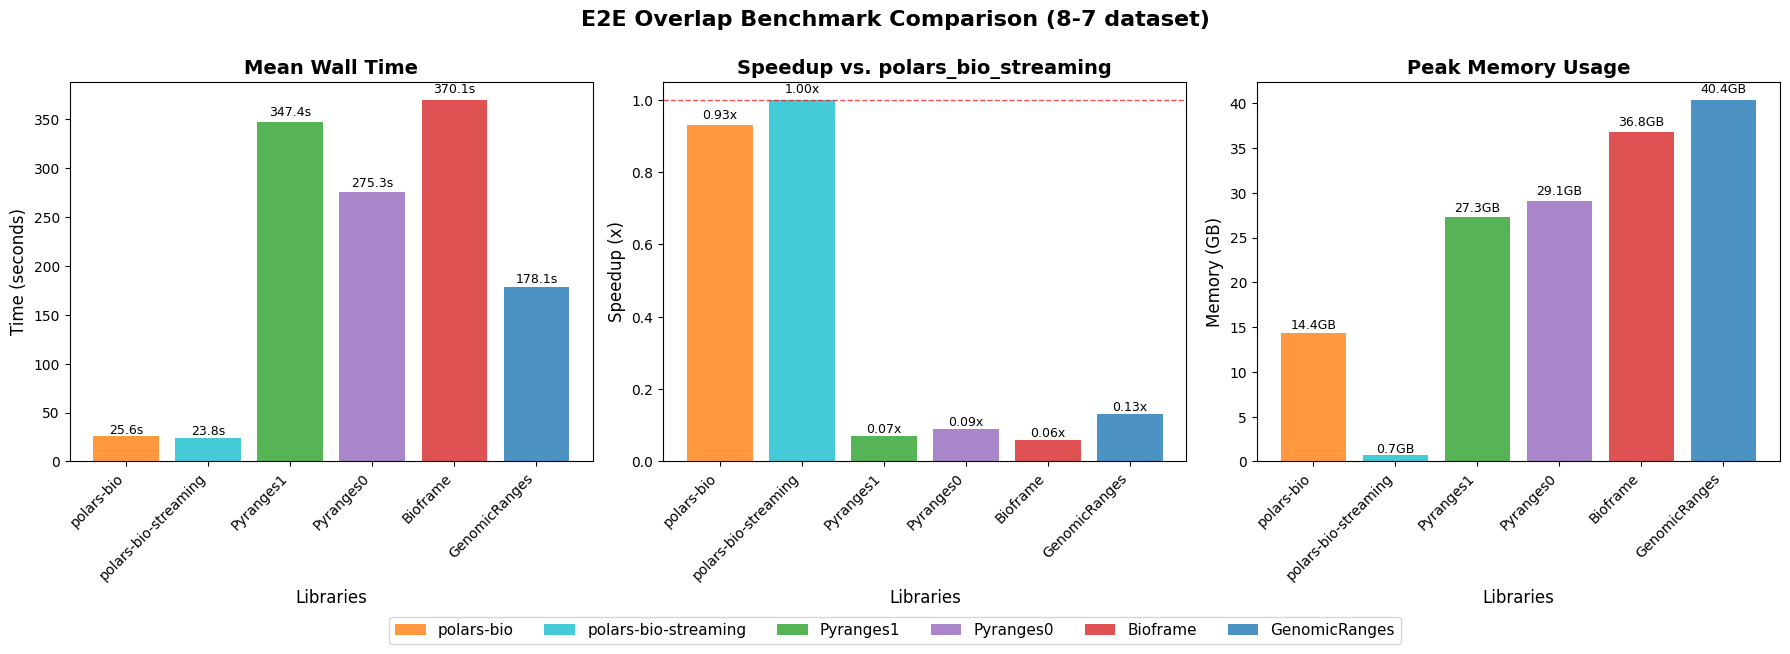

In [16]:
# Create figure with 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Mean Wall Time
ax1 = axes[0]
bars1 = ax1.bar(range(len(df)), df["Mean (s)"], color=colors, alpha=0.8)
ax1.set_title("Mean Wall Time", fontsize=14, fontweight="bold")
ax1.set_ylabel("Time (seconds)", fontsize=12)
ax1.set_xlabel("Libraries", fontsize=12)
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels(df["Library_Display"], rotation=45, ha="right", fontsize=10)

# Add value labels on bars
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.01,
        f"{height:.1f}s",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Plot 2: Speedup
ax2 = axes[1]
bars2 = ax2.bar(range(len(df)), df["Speedup_numeric"], color=colors, alpha=0.8)
ax2.set_title("Speedup vs. polars_bio_streaming", fontsize=14, fontweight="bold")
ax2.set_ylabel("Speedup (x)", fontsize=12)
ax2.set_xlabel("Libraries", fontsize=12)
ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(df["Library_Display"], rotation=45, ha="right", fontsize=10)
ax2.axhline(y=1, color="red", linestyle="--", alpha=0.7, linewidth=1)

# Add value labels on bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.01,
        f"{height:.2f}x",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Plot 3: Peak Memory
ax3 = axes[2]
# Convert MB to GB for better readability
memory_gb = df["Peak memory (MB)"] / 1024
bars3 = ax3.bar(range(len(df)), memory_gb, color=colors, alpha=0.8)
ax3.set_title("Peak Memory Usage", fontsize=14, fontweight="bold")
ax3.set_ylabel("Memory (GB)", fontsize=12)
ax3.set_xlabel("Libraries", fontsize=12)
ax3.set_xticks(range(len(df)))
ax3.set_xticklabels(df["Library_Display"], rotation=45, ha="right", fontsize=10)

# Add value labels on bars
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.01,
        f"{height:.1f}GB",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Add overall title
fig.suptitle(
    "E2E Overlap Benchmark Comparison (8-7 dataset)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Create a custom legend using the first subplot
legend_elements = []
for lib, color in color_map.items():
    if lib in df["Library"].values:
        display_name = library_display_names.get(lib, lib)
        legend_elements.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.8, label=display_name)
        )

# Place legend below the plots
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(legend_elements),
    fontsize=11,
)

plt.show()

## Save the Figure

## Poster-Ready Version (High Resolution)

Poster-ready visualization saved as: ../combined_benchmark_visualization_poster.png
Resolution: 300 DPI
Figure size: [24.  7.] inches


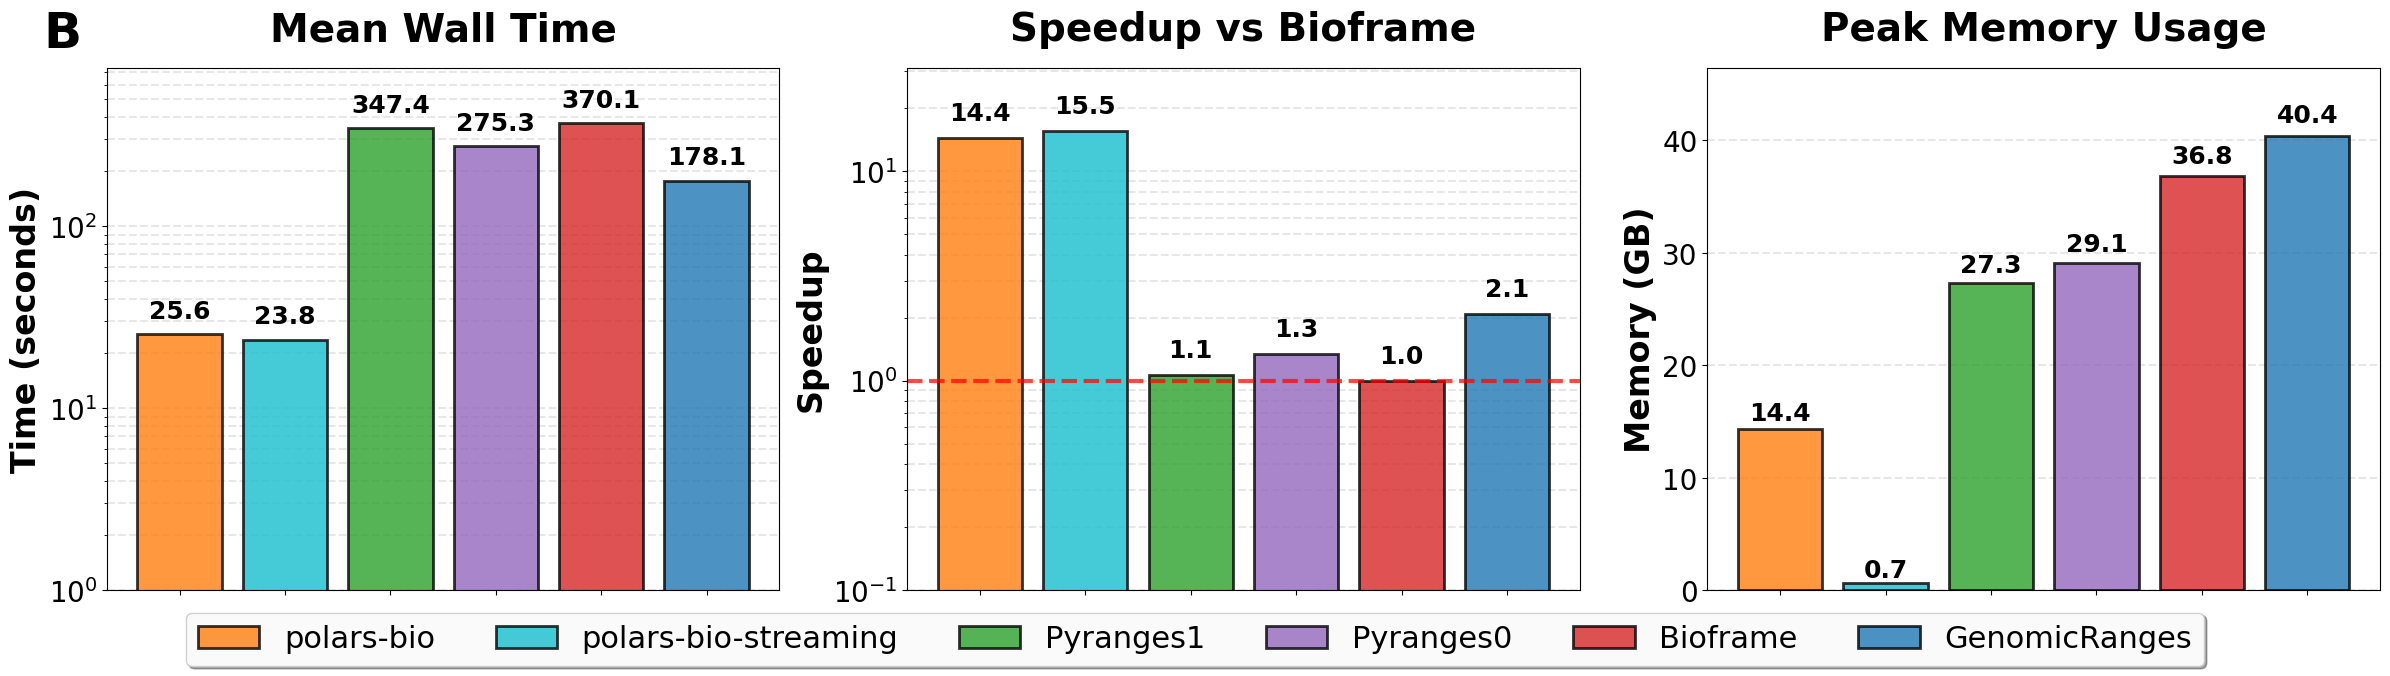

In [20]:
# Create a poster-ready version with larger fonts and higher resolution
# Optimized for poster printing with wider aspect ratio

fig_poster, axes_poster = plt.subplots(1, 3, figsize=(24, 7))

# Increased font sizes for poster visibility
title_fontsize = 28
label_fontsize = 24
tick_fontsize = 20
value_fontsize = 18

# Calculate speedup vs bioframe (baseline is the slowest)
bioframe_time = df[df["Library"] == "bioframe"]["Mean (s)"].values[0]
speedup_vs_bioframe = bioframe_time / df["Mean (s)"]

# Plot 1: Mean Wall Time (LOG SCALE starting from 1)
ax1 = axes_poster[0]
# Set log scale BEFORE plotting bars
ax1.set_yscale("log")
bars1 = ax1.bar(
    range(len(df)),
    df["Mean (s)"],
    color=colors,
    alpha=0.8,
    edgecolor="black",
    linewidth=2,
)
ax1.set_title("Mean Wall Time", fontsize=title_fontsize, fontweight="bold", pad=20)
ax1.set_ylabel("Time (seconds)", fontsize=label_fontsize, fontweight="bold")
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels([])  # Remove x-axis labels
ax1.tick_params(axis="y", labelsize=tick_fontsize)
ax1.grid(axis="y", alpha=0.3, linestyle="--", linewidth=1.5, which="both")
ax1.set_axisbelow(True)
# Set y-axis limits with extra space for labels
ax1.set_ylim(bottom=1, top=df["Mean (s)"].max() * 2)

# Add value labels on bars (without 's' suffix)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height * 1.15,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=value_fontsize,
        fontweight="bold",
    )

# Plot 2: Speedup vs Bioframe (LOG SCALE starting from 0.1)
ax2 = axes_poster[1]
# Set log scale BEFORE plotting bars
ax2.set_yscale("log")
bars2 = ax2.bar(
    range(len(df)),
    speedup_vs_bioframe,
    color=colors,
    alpha=0.8,
    edgecolor="black",
    linewidth=2,
)
ax2.set_title("Speedup vs Bioframe", fontsize=title_fontsize, fontweight="bold", pad=20)
ax2.set_ylabel("Speedup", fontsize=label_fontsize, fontweight="bold")
ax2.set_xticks(range(len(df)))
ax2.set_xticklabels([])  # Remove x-axis labels
ax2.tick_params(axis="y", labelsize=tick_fontsize)
ax2.axhline(y=1, color="red", linestyle="--", alpha=0.7, linewidth=3)
ax2.grid(axis="y", alpha=0.3, linestyle="--", linewidth=1.5, which="both")
ax2.set_axisbelow(True)
# Set y-axis limits with extra space for labels
ax2.set_ylim(bottom=0.1, top=speedup_vs_bioframe.max() * 2)

# Add value labels on bars (without 'x' suffix)
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height * 1.15,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=value_fontsize,
        fontweight="bold",
    )

# Plot 3: Peak Memory
ax3 = axes_poster[2]
# Convert MB to GB for better readability
memory_gb = df["Peak memory (MB)"] / 1024
bars3 = ax3.bar(
    range(len(df)), memory_gb, color=colors, alpha=0.8, edgecolor="black", linewidth=2
)
ax3.set_title("Peak Memory Usage", fontsize=title_fontsize, fontweight="bold", pad=20)
ax3.set_ylabel("Memory (GB)", fontsize=label_fontsize, fontweight="bold")
ax3.set_xticks(range(len(df)))
ax3.set_xticklabels([])  # Remove x-axis labels
ax3.tick_params(axis="y", labelsize=tick_fontsize)
ax3.grid(axis="y", alpha=0.3, linestyle="--", linewidth=1.5)
ax3.set_axisbelow(True)
# Set y-axis limits with extra space for labels
ax3.set_ylim(top=memory_gb.max() * 1.15)

# Add value labels on bars (without 'GB' suffix)
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.02,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=value_fontsize,
        fontweight="bold",
    )

# Add "B" label in upper-left corner of the whole figure
fig_poster.text(
    0.02,
    0.98,
    "B",
    fontsize=36,
    fontweight="bold",
    transform=fig_poster.transFigure,
    va="top",
    ha="left",
)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Create a custom legend with larger fonts
legend_elements = []
for lib, color in color_map.items():
    if lib in df["Library"].values:
        display_name = library_display_names.get(lib, lib)
        legend_elements.append(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor=color,
                alpha=0.8,
                edgecolor="black",
                linewidth=2,
                label=display_name,
            )
        )

# Place legend below the plots with larger font
fig_poster.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(legend_elements),
    fontsize=22,
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.95,
)

# Save the poster-ready plot with high DPI for printing
output_path_poster = "../combined_benchmark_visualization_poster.png"
fig_poster.savefig(
    output_path_poster, dpi=300, bbox_inches="tight", pad_inches=0.3, facecolor="white"
)
print(f"Poster-ready visualization saved as: {output_path_poster}")
print("Resolution: 300 DPI")
print(f"Figure size: {fig_poster.get_size_inches()} inches")

plt.show()

In [21]:
# Save as SVG for scalable vector graphics (perfect for posters)
output_path_svg = "../combined_benchmark_visualization_poster.svg"
fig_poster.savefig(
    output_path_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.3,
    facecolor="white",
)
print(f"Poster-ready SVG saved as: {output_path_svg}")

Poster-ready SVG saved as: ../combined_benchmark_visualization_poster.svg
